**EDA Stock Data**

Author: Jesús Enrique Miranda Blanco

In [1]:
import pandas as pd
import numpy as np
from datetime import date, timedelta

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# import pandas_datareader.data as web
import yfinance as yf


pd.set_option("display.max_columns",80)

In [2]:
yesterday = str(date.today() - timedelta(days = 1))
print("Today's date:", yesterday)

Today's date: 2023-02-13


In [5]:
%%time
start_date = "2019-01-01"
tickers = ['MAT','DIS','KO', 'NVDA','PFE','MRNA', "AAPL", "META", "TSLA", "^GSPC","MSFT", "NU"]
print(f"The number of stock to download are {len(tickers)}")
all_data = yf.download(tickers, start_date, yesterday)
all_data.info()

The number of stock to download are 12
[*********************100%***********************]  12 of 12 completed
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1036 entries, 2019-01-02 00:00:00-05:00 to 2023-02-10 00:00:00-05:00
Data columns (total 72 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Adj Close, AAPL)   1036 non-null   float64
 1   (Adj Close, DIS)    1036 non-null   float64
 2   (Adj Close, KO)     1036 non-null   float64
 3   (Adj Close, MAT)    1036 non-null   float64
 4   (Adj Close, META)   1036 non-null   float64
 5   (Adj Close, MRNA)   1036 non-null   float64
 6   (Adj Close, MSFT)   1036 non-null   float64
 7   (Adj Close, NU)     295 non-null    float64
 8   (Adj Close, NVDA)   1036 non-null   float64
 9   (Adj Close, PFE)    1036 non-null   float64
 10  (Adj Close, TSLA)   1036 non-null   float64
 11  (Adj Close, ^GSPC)  1036 non-null   float64
 12  (Close, AAPL)       1036 non-null   float64


# Missing review

In [6]:
df_missings_agg = all_data.isna().sum().sort_values()
df_missings_agg[
    df_missings_agg > 0
]

Low        NU    741
Adj Close  NU    741
Open       NU    741
Volume     NU    741
Close      NU    741
High       NU    741
dtype: int64

In [14]:
adj_close_data = all_data["Adj Close"].copy()
adj_close_data.head()

,AAPL,DIS,KO,MAT,META,MRNA,MSFT,NU,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,,,
2019-01-02 00:00:00-05:00,38.047043,107.654335,41.413986,9.76,135.679993,15.330000,96.874702,NaN,33.805470,35.108093,20.674667,2510.030029
2019-01-03 00:00:00-05:00,34.257286,105.046211,41.158077,9.27,131.740005,15.500000,93.310867,NaN,31.763046,34.125874,20.024000,2447.889893
2019-01-04 00:00:00-05:00,35.719704,108.286606,41.978775,10.41,137.949997,16.959999,97.650688,NaN,33.798027,34.905151,21.179333,2531.939941
2019-01-07 00:00:00-05:00,35.640190,109.225136,41.431644,11.21,138.050003,16.270000,97.775230,NaN,35.587318,35.091858,22.330667,2549.689941
2019-01-08 00:00:00-05:00,36.319611,110.074760,41.899338,11.74,142.529999,16.950001,98.484161,NaN,34.701355,35.254208,22.356667,2574.409912


In [15]:
adj_close_data[
    adj_close_data.NU.notna()
].isna().sum()#.index.min()

AAPL     0
DIS      0
KO       0
MAT      0
META     0
MRNA     0
MSFT     0
NU       0
NVDA     0
PFE      0
TSLA     0
^GSPC    0
dtype: int64

In [16]:
adj_close_data[
    adj_close_data.NU.notna()
].index.min()

Timestamp('2021-12-09 00:00:00-0500', tz='America/New_York')

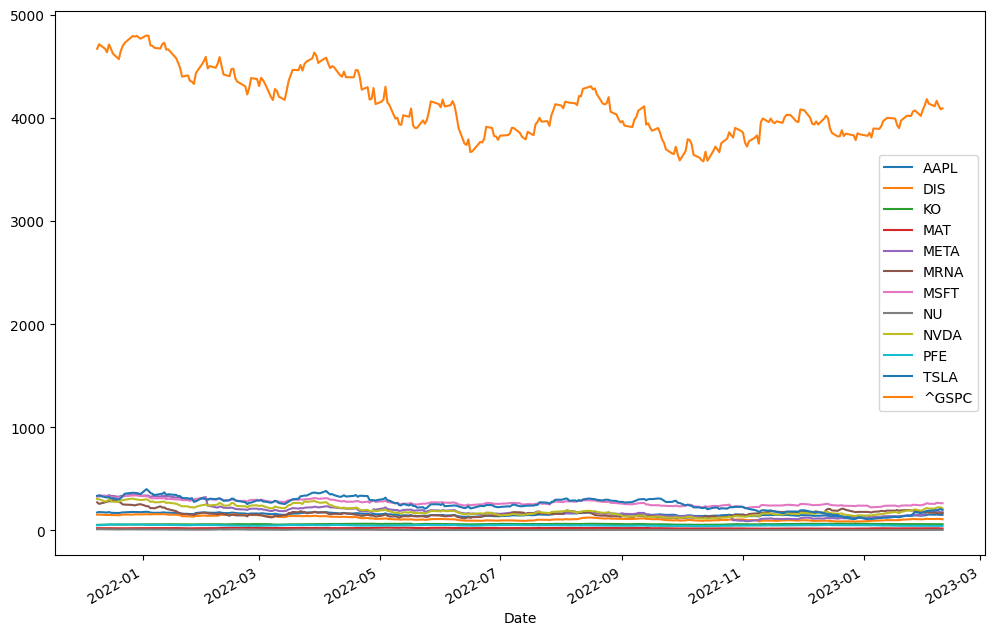

In [17]:
adj_close_data[
    adj_close_data.NU.notna()
].plot(
    figsize=(12,8)
);

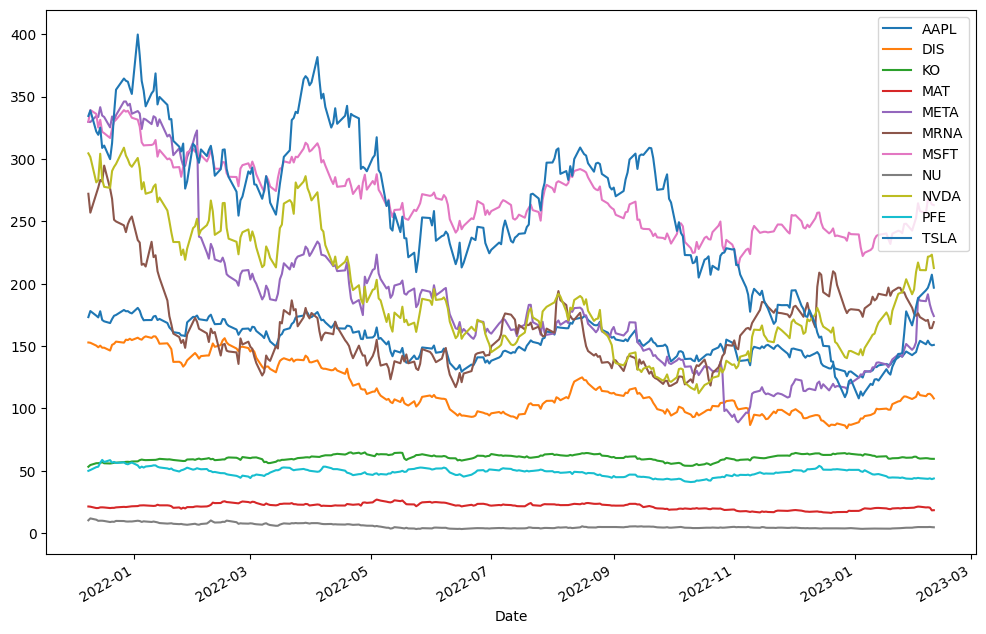

In [18]:
adj_close_data[
    adj_close_data.NU.notna()
].drop(
    columns=["^GSPC"]
).plot(
    figsize=(12,8)
);

In [25]:
"AAPL" in adj_close_data.columns

True

In [26]:
"prueba" in adj_close_data.columns

False

In [29]:
adj_close_data = adj_close_data.drop(columns=['NU','prueba'],errors='ignore')
adj_close_data.head()

,AAPL,DIS,KO,MAT,META,MRNA,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,,
2019-01-02 00:00:00-05:00,38.047043,107.654335,41.413986,9.76,135.679993,15.330000,96.874702,33.805470,35.108093,20.674667,2510.030029
2019-01-03 00:00:00-05:00,34.257286,105.046211,41.158077,9.27,131.740005,15.500000,93.310867,31.763046,34.125874,20.024000,2447.889893
2019-01-04 00:00:00-05:00,35.719704,108.286606,41.978775,10.41,137.949997,16.959999,97.650688,33.798027,34.905151,21.179333,2531.939941
2019-01-07 00:00:00-05:00,35.640190,109.225136,41.431644,11.21,138.050003,16.270000,97.775230,35.587318,35.091858,22.330667,2549.689941
2019-01-08 00:00:00-05:00,36.319611,110.074760,41.899338,11.74,142.529999,16.950001,98.484161,34.701355,35.254208,22.356667,2574.409912


In [31]:
(34.309586 - 38.105137) / 38.105137

-0.09960733115852585

In [32]:
(35.774239- 34.309586) / 34.309586

0.042689323036424816

In [31]:
yield_data = adj_close_data.pct_change()#.dropna()
yield_data.head()

,AAPL,DIS,KO,MAT,META,MRNA,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,,
2019-01-02 00:00:00-05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03 00:00:00-05:00,-0.099607,-0.024227,-0.006179,-0.050205,-0.029039,0.011089,-0.036788,-0.060417,-0.027977,-0.031472,-0.024757
2019-01-04 00:00:00-05:00,0.042689,0.030847,0.019940,0.122977,0.047138,0.094193,0.046509,0.064068,0.022835,0.057697,0.034336
2019-01-07 00:00:00-05:00,-0.002226,0.008667,-0.013034,0.076849,0.000725,-0.040684,0.001275,0.052941,0.005349,0.054361,0.007010
2019-01-08 00:00:00-05:00,0.019063,0.007779,0.011288,0.047279,0.032452,0.041795,0.007251,-0.024895,0.004626,0.001164,0.009695


In [32]:
yield_data = adj_close_data.pct_change().dropna()
yield_data.head()

,AAPL,DIS,KO,MAT,META,MRNA,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,,
2019-01-03 00:00:00-05:00,-0.099607,-0.024227,-0.006179,-0.050205,-0.029039,0.011089,-0.036788,-0.060417,-0.027977,-0.031472,-0.024757
2019-01-04 00:00:00-05:00,0.042689,0.030847,0.019940,0.122977,0.047138,0.094193,0.046509,0.064068,0.022835,0.057697,0.034336
2019-01-07 00:00:00-05:00,-0.002226,0.008667,-0.013034,0.076849,0.000725,-0.040684,0.001275,0.052941,0.005349,0.054361,0.007010
2019-01-08 00:00:00-05:00,0.019063,0.007779,0.011288,0.047279,0.032452,0.041795,0.007251,-0.024895,0.004626,0.001164,0.009695
2019-01-09 00:00:00-05:00,0.016982,0.011219,-0.019166,-0.009370,0.011927,-0.036578,0.014300,0.019667,-0.002072,0.009483,0.004098


In [34]:
df_log = np.log(yield_data + 1)
df_log.head()

,AAPL,DIS,KO,MAT,META,MRNA,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,,
2019-01-03 00:00:00-05:00,-0.104924,-0.024525,-0.006198,-0.051509,-0.029469,0.011028,-0.037482,-0.062319,-0.028376,-0.031978,-0.025068
2019-01-04 00:00:00-05:00,0.041803,0.030381,0.019744,0.115983,0.046061,0.090018,0.045460,0.062099,0.022579,0.056094,0.033759
2019-01-07 00:00:00-05:00,-0.002229,0.008630,-0.013119,0.074039,0.000725,-0.041535,0.001275,0.051587,0.005335,0.052935,0.006986
2019-01-08 00:00:00-05:00,0.018884,0.007749,0.011225,0.046196,0.031937,0.040945,0.007224,-0.025211,0.004616,0.001164,0.009649
2019-01-09 00:00:00-05:00,0.016839,0.011156,-0.019352,-0.009414,0.011857,-0.037264,0.014198,0.019476,-0.002075,0.009438,0.004090


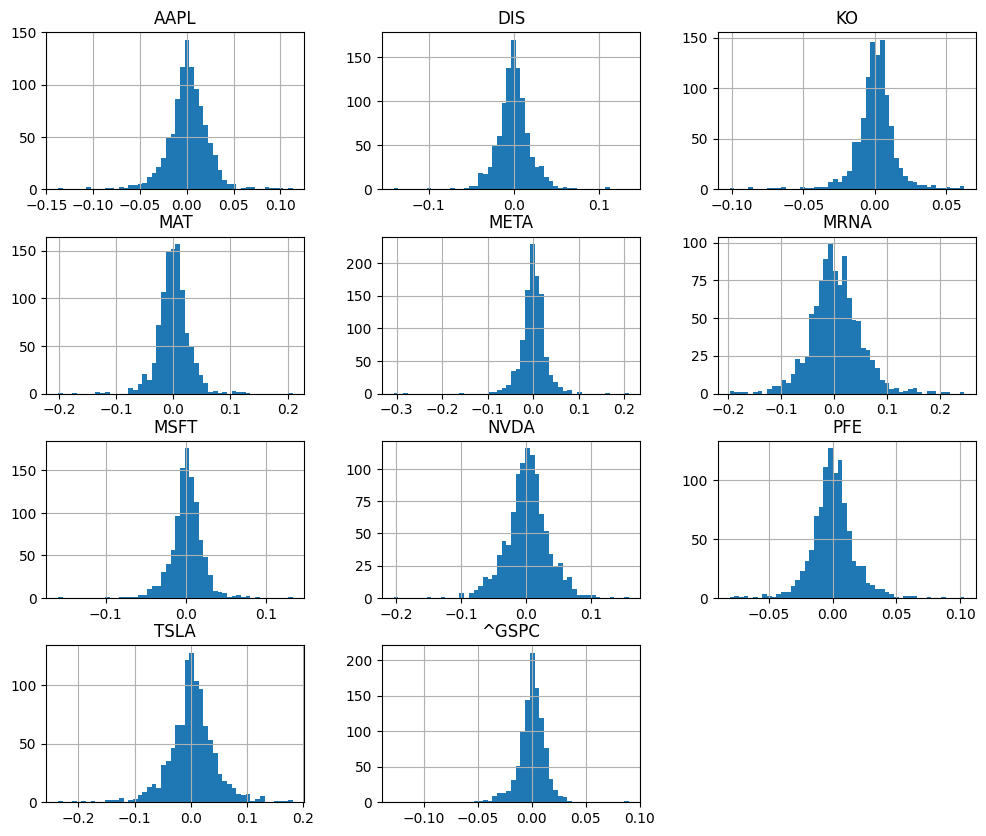

In [38]:
df_log.hist(figsize=(12,10), bins=50);